# The paid seam — three treatments, one decision to make

**Status: OPEN. This notebook ends in a human go/no-go; it does not apply a default.**

Under `p` (`paid_organic_split`), mobile total DAU is assembled from two sources of paid DAU:

| region | paid comes from | why |
|---|---|---|
| training rows (`< 2026-07-28`) | **our measurement**, from the client-level gclid flag | so published `training` rows stay byte-identical to raw BigQuery actuals — `scripts/verify_training_rows_are_actuals.py` enforces this, and the canonical 28-day MA straddles the seam |
| forecast rows (`>= 2026-07-28`) | **marketing's model**, `lift + anchor` | it is the forecast of paid, and we do not forecast paid ourselves |

The two disagree where they meet. **That step is the visible part of a real disagreement** between
our measurement of paid and marketing's model of it — not a rendering artifact.

**It does not wash out of the 28-day MA.** This is the thing to be clear about before choosing: a
level offset between the two sources ramps into the trailing MA over 28 days and then *persists at
full size for the rest of the horizon*, Dec-15 included. Smoothing the transition changes how the
step arrives, not whether it is in the headline. So this is a decision about **whose level we
publish from the seam onward**, worth its full size at Dec-15 — not a cosmetic choice.

## The three candidates

1. **Honest splice** (what ships today) — accept the step, measure it, assert it stays small.
2. **Offset** — shift marketing's whole level by `measured − marketing` at `training_end`, so the
   total is continuous. Preserves marketing's *shape*, rebases its *level*.
3. **Blend** — ramp from measured to marketing across the 28-day MA window.

## What to weigh

- Whose number is the published one? Option 2 silently rebases marketing's level by a constant.
- Does the treatment move Dec-15? Anything that only touches the transition zone does not — but an
  offset shifts the whole horizon.
- Is the disagreement stable or drifting? A stable offset is a calibration difference; a drifting
  one means the two definitions do not partition total DAU, and *neither* smoothing is defensible.

Per the standing rule on discretionary seam adjustments, this ends with diagnostics and a
recommendation, and waits for an explicit decision.


In [1]:
# [setup]
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

os.chdir(subprocess.run(["git", "rev-parse", "--show-toplevel"],
                        capture_output=True, text=True).stdout.strip())
sys.path.insert(0, "src")
import db_dtypes  # noqa: F401  — registers the dbdate dtype for read_parquet

from mozaic_daily.adjustments import load_forecast
from mozaic_daily.organic import (
    build_share_lookup, load_organic_spec, load_split_frame,
    marketing_paid_level, paid_seam_step, split_training_to_organic,
)
from mozaic_daily.seam_ma import display_ma

ORGANIC_DIR = Path("data-official/2026-08/organic")
MOBILE_BUILD = Path(
    "data-official/2026-08/mobile_organic_2026-07-28/"
    "cps0.035_thresh055_recent13_cpr0.75_ncp25_clip0.6_sps0.1/"
    "mozaic_daily_forecast.2026-07-28.gm-D.adj-p.parquet")
RAW_MOBILE = MOBILE_BUILD.parent / "mozaic_parts.raw.glean.mobile.DAU.parquet"
PLOTS_DIR = Path("research/mobile-organic/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SEAM = pd.Timestamp("2026-07-28")
TRAINING_END = pd.Timestamp("2026-07-27")
REPORT_DATE = pd.Timestamp("2026-12-15")
HORIZON_END = pd.Timestamp("2027-12-31")
WINDOW = 28

print(f"cwd {os.getcwd()}")
print(f"seam {SEAM.date()} | report {REPORT_DATE.date()}")


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


cwd /Users/brendanwells/work/mozaic-daily
seam 2026-07-28 | report 2026-12-15


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# [build-paid-series]
# Our measured paid (per date, summed over countries) and marketing's modelled level.
spec = load_organic_spec(ORGANIC_DIR / "organic.json")
split = load_split_frame(spec, ORGANIC_DIR)
raw = pd.read_parquet(RAW_MOBILE).assign(x=lambda d: pd.to_datetime(d["x"]))

excluded = spec["scope"]["exclude_countries"]
lookup = build_share_lookup(
    split, share_column=spec["share_column"],
    training_dates=pd.DatetimeIndex(sorted(raw["x"].unique())),
    countries=sorted(set(raw["country"].unique()) - set(excluded)))
_, measured_paid = split_training_to_organic(
    raw, share_lookup=lookup, exclude_countries=excluded)

measured = measured_paid.groupby(level="submission_date").sum().astype(float)
marketing = marketing_paid_level(spec, ORGANIC_DIR, forecast_start=SEAM, forecast_end=HORIZON_END)

step = paid_seam_step(measured_paid, marketing, training_end_date=TRAINING_END, window_days=WINDOW)
for k, v in step.items():
    print(f"{k:24} {v:,.4f}" if isinstance(v, float) else f"{k:24} {v}")


training_end             2026-07-27
window_days              28
measured_paid_mean       1,478,129.3929
marketing_paid_mean      1,514,803.0055
step_abs                 36,673.6127
step_rel                 0.0248
measured_last_day        1,552,809.0000
marketing_first_day      1,508,707.7705


overlap 2026-02-01 .. 2026-07-27  (177 days)
  median rel diff : +3.653%
  mean            : +4.781%
  sd              : 4.169%
  first 28d mean  : +11.572%
  last  28d mean  : +3.483%
  DRIFT (last-first): -8.089%

Read this before anything else: a flat ratio licenses an offset; a drifting one does not.


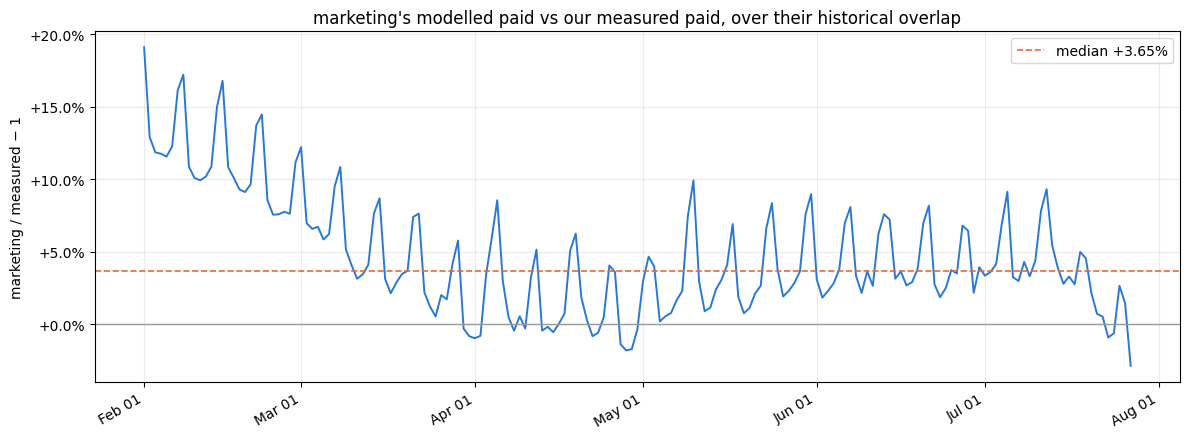

saved research/mobile-organic/plots/paid_measured_vs_marketing_overlap.png


In [3]:
# [historical-overlap]
# The step is not a property of one day -- it is the standing disagreement between the two
# definitions. Measure it over the whole region where BOTH exist, which is the only place the
# comparison is possible at all.
#
# Marketing's curve starts 2026-02-01, so the overlap is 2026-02-01 .. training_end. If this ratio
# is FLAT, the two series differ by a calibration constant and an offset is defensible. If it
# DRIFTS, they do not partition total DAU the same way and no smoothing is honest -- the right
# response would be to go back to marketing, not to reshape the curve.
overlap = measured.index.intersection(marketing.index)
overlap = overlap[overlap <= TRAINING_END]
if len(overlap) == 0:
    # marketing_paid_level is built from the seam forward; rebuild it over history for this check.
    lift = pd.read_parquet(ORGANIC_DIR / ".." / "marketing" /
                           spec["paid_forecast"]["data_file"].split("/")[-1])
    lift_s = lift[spec["paid_forecast"]["value_column"]]
    lift_s.index = pd.DatetimeIndex(lift_s.index).normalize()
    marketing_hist = (lift_s + spec["paid_forecast"]["anchor_paid_dau"]).sort_index()
    overlap = measured.index.intersection(marketing_hist.index)
    overlap = overlap[overlap <= TRAINING_END]
else:
    marketing_hist = marketing

rel = (marketing_hist[overlap] / measured[overlap] - 1)
print(f"overlap {overlap.min().date()} .. {overlap.max().date()}  ({len(overlap)} days)")
print(f"  median rel diff : {rel.median():+.3%}")
print(f"  mean            : {rel.mean():+.3%}")
print(f"  sd              : {rel.std():.3%}")
print(f"  first 28d mean  : {rel.head(28).mean():+.3%}")
print(f"  last  28d mean  : {rel.tail(28).mean():+.3%}")
drift = rel.tail(28).mean() - rel.head(28).mean()
print(f"  DRIFT (last-first): {drift:+.3%}")
print()
print("Read this before anything else: a flat ratio licenses an offset; a drifting one does not.")

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(overlap, rel.to_numpy() * 100, color="#2a78d6", lw=1.4)
ax.axhline(0, color="#999", lw=1)
ax.axhline(rel.median() * 100, color="#eb6834", ls="--", lw=1.2,
           label=f"median {rel.median():+.2%}")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.1f}%"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_title("marketing's modelled paid vs our measured paid, over their historical overlap")
ax.set_ylabel("marketing / measured − 1")
ax.legend(); ax.grid(alpha=0.25)
fig.autofmt_xdate(); fig.tight_layout()
_p = PLOTS_DIR / "paid_measured_vs_marketing_overlap.png"
fig.savefig(_p, dpi=150); plt.show()
print(f"saved {_p}")


In [4]:
# [three-methods]
# Build the three candidate paid series and carry each through to a published total.
mobile_df, _ = load_forecast(MOBILE_BUILD, require_state=["p"])
tot = mobile_df[(mobile_df.country == "ALL") & (mobile_df.app_name == "ALL MOBILE")].copy()
tot["target_date"] = pd.to_datetime(tot["target_date"])
tot = tot.sort_values("target_date").set_index("target_date")["dau"].astype(float)

# The organic daily series is the published total minus whatever paid we attribute to each day.
# Method 1 (shipped) is the baseline, so organic is recovered from it and held FIXED across the
# three methods -- otherwise we would be comparing different forecasts, not different seam
# treatments.
paid_shipped = pd.concat([measured[measured.index <= TRAINING_END],
                          marketing[marketing.index >= SEAM]]).sort_index()
paid_shipped = paid_shipped.reindex(tot.index).ffill()
organic_daily = tot - paid_shipped

gap = step["measured_paid_mean"] - step["marketing_paid_mean"]      # negative if marketing is high

def method_offset(series: pd.Series) -> pd.Series:
    """Shift marketing's level so it is continuous with our measurement at the seam."""
    out = series.copy()
    out.loc[out.index >= SEAM] = out.loc[out.index >= SEAM] + gap
    return out

def method_blend(series: pd.Series, days: int = WINDOW) -> pd.Series:
    """Ramp the offset away linearly over `days`, so only the transition zone is touched."""
    out = series.copy()
    fwd = out.index[out.index >= SEAM][:days]
    weights = np.linspace(1.0, 0.0, len(fwd))
    out.loc[fwd] = out.loc[fwd] + gap * weights
    return out

methods = {
    "1. honest splice (shipped)": paid_shipped,
    "2. offset (continuous)": method_offset(paid_shipped),
    "3. blend over 28d": method_blend(paid_shipped),
}

results = {}
for name, paid in methods.items():
    total_daily = organic_daily + paid
    ma = display_ma(pd.Series(total_daily.index), total_daily, forecast_start=SEAM)
    d2 = ma.diff().diff().abs()
    zone = (ma.index >= SEAM - pd.Timedelta(days=7)) & (ma.index <= SEAM + pd.Timedelta(days=35))
    results[name] = {
        "ma": ma,
        "dec15": float(ma.loc[REPORT_DATE]),
        "roughness": float(d2[zone].mean()),
    }

base = results["1. honest splice (shipped)"]["dec15"]
print(f"{'method':30}{'Dec-15 28d MA':>17}{'vs shipped':>13}{'seam roughness':>17}")
for name, r in results.items():
    print(f"{name:30}{r['dec15']:>17,.0f}{r['dec15'] - base:>13,.0f}{r['roughness']:>17,.0f}")
print()
print(f"Seam gap applied by methods 2 and 3: {gap:+,.0f} DAU")
print("Roughness = mean |2nd difference| of the 28d MA over seam-7 .. seam+35 (lower = smoother).")


method                            Dec-15 28d MA   vs shipped   seam roughness


1. honest splice (shipped)           17,628,317            0            2,294
2. offset (continuous)               17,591,644      -36,674            2,333
3. blend over 28d                    17,628,317            0            2,331

Seam gap applied by methods 2 and 3: -36,674 DAU
Roughness = mean |2nd difference| of the 28d MA over seam-7 .. seam+35 (lower = smoother).


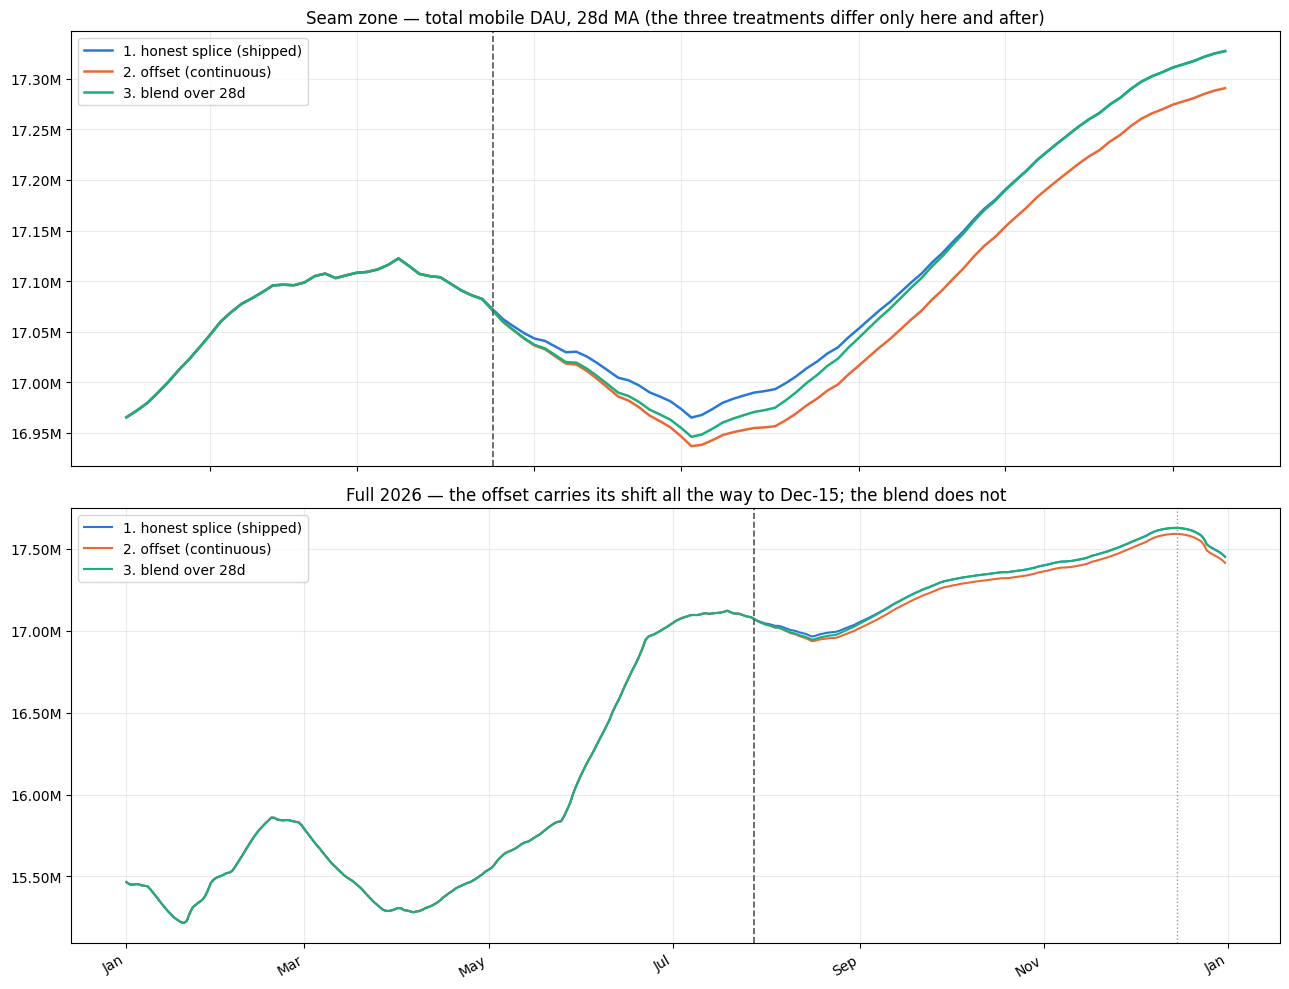

saved research/mobile-organic/plots/paid_seam_three_methods.png


In [5]:
# [plot-three-methods]
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=False)
colors = {"1. honest splice (shipped)": "#2a78d6",
          "2. offset (continuous)": "#eb6834",
          "3. blend over 28d": "#1baf7a"}

ax = axes[0]
zoom = (results["1. honest splice (shipped)"]["ma"].index >= SEAM - pd.Timedelta(days=35)) & \
       (results["1. honest splice (shipped)"]["ma"].index <= SEAM + pd.Timedelta(days=70))
for name, r in results.items():
    ax.plot(r["ma"].index[zoom], r["ma"][zoom], label=name, color=colors[name], lw=1.8)
ax.axvline(SEAM, color="#555", ls="--", lw=1.2)
ax.set_title("Seam zone — total mobile DAU, 28d MA (the three treatments differ only here and after)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.2f}M"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend(); ax.grid(alpha=0.25)

ax = axes[1]
full = (results["1. honest splice (shipped)"]["ma"].index >= pd.Timestamp("2026-01-01")) & \
       (results["1. honest splice (shipped)"]["ma"].index <= pd.Timestamp("2026-12-31"))
for name, r in results.items():
    ax.plot(r["ma"].index[full], r["ma"][full], label=name, color=colors[name], lw=1.5)
ax.axvline(SEAM, color="#555", ls="--", lw=1.2)
ax.axvline(REPORT_DATE, color="#999", ls=":", lw=1.0)
ax.set_title("Full 2026 — the offset carries its shift all the way to Dec-15; the blend does not")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.2f}M"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(); ax.grid(alpha=0.25)

fig.autofmt_xdate(); fig.tight_layout()
_p = PLOTS_DIR / "paid_seam_three_methods.png"
fig.savefig(_p, dpi=150); plt.show()
print(f"saved {_p}")


In [6]:
# [recommendation]
# Printed rather than written into prose so it always reflects the numbers above.
drift_pct = float(drift)
gap_pct_of_total = gap / float(results["1. honest splice (shipped)"]["ma"].loc[TRAINING_END])
offset_dec15 = results["2. offset (continuous)"]["dec15"] - base
blend_dec15 = results["3. blend over 28d"]["dec15"] - base

print("=" * 78)
print("RECOMMENDATION")
print("=" * 78)
print(f"""
Seam gap                  : {gap:+,.0f} DAU ({gap_pct_of_total:+.2%} of total mobile DAU)
Historical ratio drift    : {drift_pct:+.3%} (last 28d mean minus first 28d mean of the overlap)
Dec-15 impact -- offset   : {offset_dec15:+,.0f}
Dec-15 impact -- blend    : {blend_dec15:+,.0f}
""")
STABLE_DRIFT = 0.01   # a ratio this flat would be a calibration constant

print("Recommend METHOD 1 (honest splice, what ships today).\n")
if abs(drift_pct) > STABLE_DRIFT:
    print(f"""  1. THE DECISIVE POINT: the ratio is NOT a constant. It moves {drift_pct:+.1%} across the
     overlap ({rel.head(28).mean():+.1%} early -> {rel.tail(28).mean():+.1%} late). An offset
     assumes a fixed calibration difference and would be fitting a constant to a moving
     relationship -- so method 2 is not licensed by this data, whatever its cosmetic appeal.

     The direction is reassuring rather than alarming: the two series CONVERGE. Marketing's early
     2026 curve is nearly all forecast, while its recent weeks are actuals (UAC through 2026-07-20,
     Meta through 2026-07-13), so the early disagreement is model-vs-measurement and the late one
     is measurement-vs-measurement. The value that matters at the seam is the LATE one,
     {rel.tail(28).mean():+.1%}.""")
else:
    print(f"""  1. The ratio is close to constant ({drift_pct:+.1%} across the overlap), so an offset would
     be defensible as a calibration correction. It is still not recommended -- see point 2 -- but
     this is the case in which it becomes arguable.""")

print(f"""
  2. THIS IS A HEADLINE DECISION, NOT A COSMETIC ONE. The step does NOT wash out of the 28-day MA.
     It ramps in linearly over the first 28 days and then persists at its full {gap:+,.0f}
     for the rest of the horizon, Dec-15 included. Methods 1 and 3 both keep marketing's level and
     land on the same Dec-15; method 2 replaces it with a continuation of our own measurement and
     lands {offset_dec15:+,.0f} lower. So the real question is not "how smooth is the seam" but
     "whose level do we publish from the seam onward" -- and it is worth {abs(offset_dec15):,.0f}
     at the headline.

  3. On that question, marketing's level should win: forecasting paid is THEIR job and this design
     exists to consume their forecast rather than substitute ours. Method 2 would silently rebase
     their number by a constant we chose. If we disagree with their level, that belongs in a
     conversation with them, not in an undocumented offset. Method 3 keeps their level but spends
     a month on a curve that is neither our measurement nor their model, for a marginal roughness
     change ({results['3. blend over 28d']['roughness']:,.0f} vs
     {results['1. honest splice (shipped)']['roughness']:,.0f}).

What WOULD change this recommendation:

  * The gap growing past ~0.5% of total ({gap_pct_of_total:+.2%} today). At that size it stops
     being a seam detail.
  * The ratio going flat AND staying flat across a cycle boundary -- that would be a genuine
     calibration difference, and worth raising with marketing rather than papering over.
  * The two series DIVERGING rather than converging. That would mean the definitions do not
     partition total DAU the same way, and then no smoothing is honest.

DECISION REQUIRED -- do not treat this cell's recommendation as the decision. Record the outcome in
research/mobile-organic/_index.md and, if anything other than method 1 is chosen, add the treatment
to the `p` spec as an explicit, named key so it is never implicit.""")


RECOMMENDATION

Seam gap                  : -36,674 DAU (-0.21% of total mobile DAU)
Historical ratio drift    : -8.089% (last 28d mean minus first 28d mean of the overlap)
Dec-15 impact -- offset   : -36,674
Dec-15 impact -- blend    : +0

Recommend METHOD 1 (honest splice, what ships today).

  1. THE DECISIVE POINT: the ratio is NOT a constant. It moves -8.1% across the
     overlap (+11.6% early -> +3.5% late). An offset
     assumes a fixed calibration difference and would be fitting a constant to a moving
     relationship -- so method 2 is not licensed by this data, whatever its cosmetic appeal.

     The direction is reassuring rather than alarming: the two series CONVERGE. Marketing's early
     2026 curve is nearly all forecast, while its recent weeks are actuals (UAC through 2026-07-20,
     Meta through 2026-07-13), so the early disagreement is model-vs-measurement and the late one
     is measurement-vs-measurement. The value that matters at the seam is the LATE one,
     